Fase A: Análisis Exploratorio Espacial - Generación de la cartografía de siniestralidad...
--------------------------------------------------
Cartografía generada y exportada en alta resolución: mapa_incendios_historicos.png
--------------------------------------------------


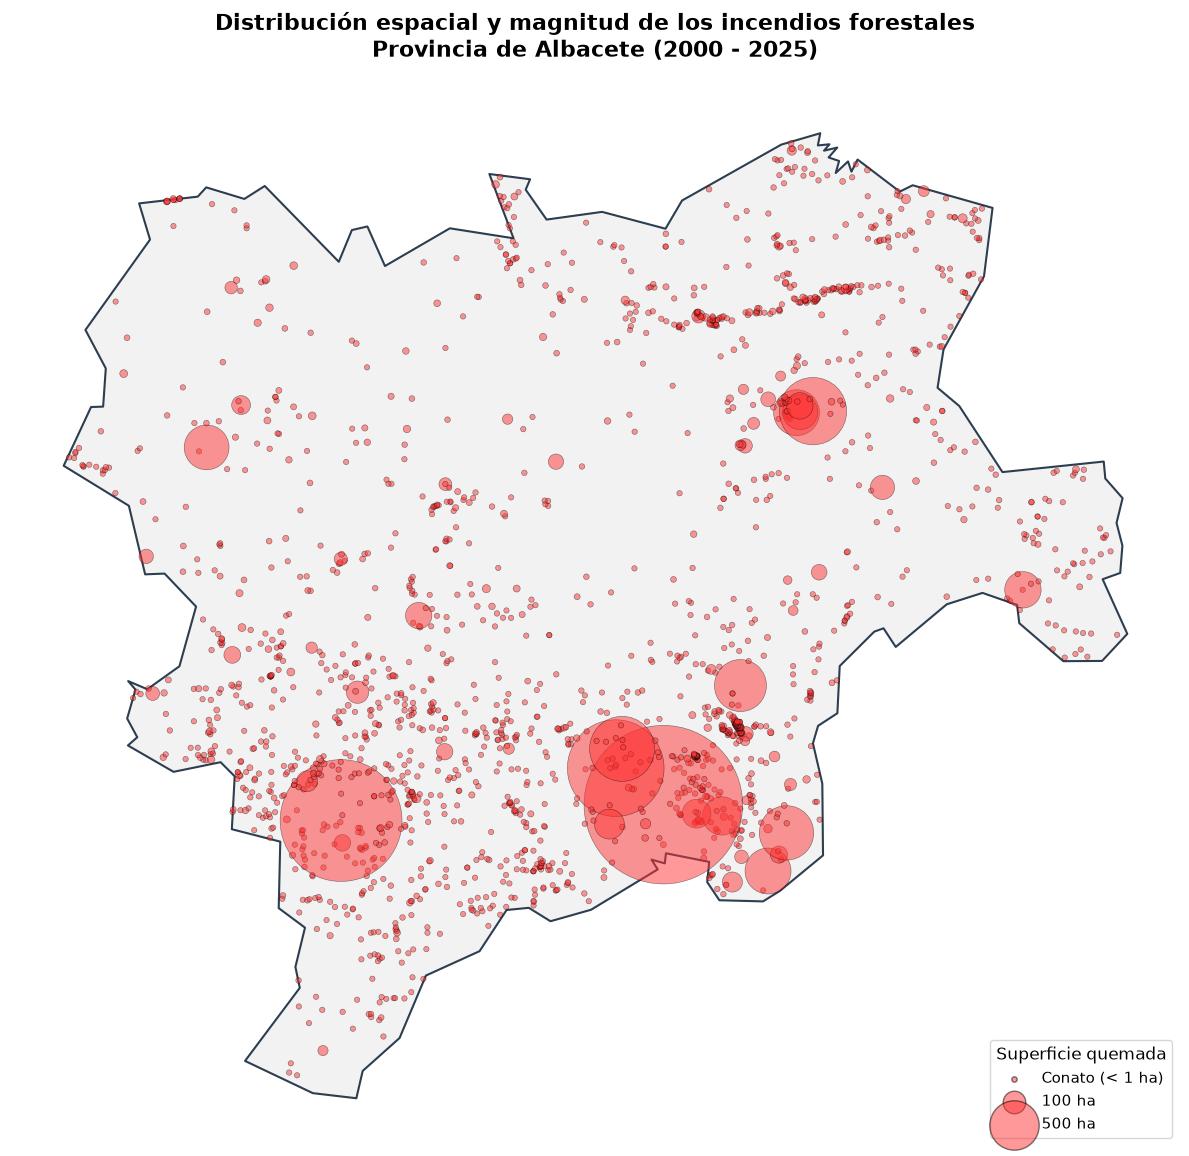

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

print("Fase A: Análisis Exploratorio Espacial - Generación de la cartografía de siniestralidad...")

# --- 1. CARGA DEL CONJUNTO DE DATOS DE INCENDIOS ---
# Se utiliza el dataset validado y geolocalizado procedente de la Fase A
ruta_archivo = '../DATOS/1.INCENDIOS/BASE_INCENDIOS_LATLON.csv' 
df = pd.read_csv(ruta_archivo)

# --- 2. CÁLCULO DE LA SUPERFICIE TOTAL AFECTADA ---
df['superficie_total'] = df['superficie_arbolada'].fillna(0) + df['superficie_no_arbolada'].fillna(0)

# --- 3. DEFINICIÓN DE LA MAGNITUD ESCALAR ---
# Parametrización geométrica para la representación proporcional de los eventos
TAMAÑO_BASE = 15
FACTOR_ESCALA = 2.5 
df['tamaño_punto'] = TAMAÑO_BASE + (df['superficie_total'] * FACTOR_ESCALA)

# --- 4. TRANSFORMACIÓN ESPACIAL A GEODATAFRAME ---
# Conversión tabular a estructura vectorial para su procesamiento con GeoPandas
geometry = [Point(xy) for xy in zip(df['Longitud'], df['Latitud'])]
gdf_incendios = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

# --- 5. ADQUISICIÓN DE LA GEOMETRÍA ADMINISTRATIVA ---
# Descarga del polígono oficial de las provincias de España
url_geojson = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/spain-provinces.geojson"
mapa_espana = gpd.read_file(url_geojson)

# Extracción de la geometría correspondiente a la provincia de Albacete
mapa_albacete = mapa_espana[mapa_espana['name'] == 'Albacete']

# --- 6. ENMASCARAMIENTO GEOGRÁFICO (SPATIAL CLIP) ---
# Filtrado de eventos mediante la intersección con el polígono administrativo
gdf_incendios = gpd.clip(gdf_incendios, mapa_albacete)

# --- 7. RENDERIZADO CARTOGRÁFICO ---
fig, ax = plt.subplots(figsize=(12, 12)) 

# Capa base: Límite administrativo de la provincia
mapa_albacete.plot(ax=ax, color='#f2f2f2', edgecolor='#2c3e50', linewidth=1.5)

# Capa de eventos: Puntos de ignición escalados por superficie
# Se emplea un factor de transparencia (alpha) para identificar zonas de alta densidad
gdf_incendios.plot(ax=ax,
                   markersize=gdf_incendios['tamaño_punto'],
                   color='#ff3333',
                   alpha=0.5,
                   edgecolor='black',
                   linewidth=0.4)

# --- 8. CONFIGURACIÓN ESTÉTICA Y LEYENDA ---
plt.title('Distribución espacial y magnitud de los incendios forestales\nProvincia de Albacete (2000 - 2025)',
          fontsize=16, fontweight='bold', pad=20)

# Ocultación de los ejes coordenados para una presentación limpia
ax.axis('off')

# Construcción manual de la leyenda de magnitudes
leyenda_puntos = [
    plt.scatter([], [], s=TAMAÑO_BASE, color='#ff3333', alpha=0.5, edgecolor='black', label='Conato (< 1 ha)'),
    plt.scatter([], [], s=TAMAÑO_BASE + (100 * FACTOR_ESCALA), color='#ff3333', alpha=0.5, edgecolor='black', label='100 ha'),
    plt.scatter([], [], s=TAMAÑO_BASE + (500 * FACTOR_ESCALA), color='#ff3333', alpha=0.5, edgecolor='black', label='500 ha')
]
plt.legend(handles=leyenda_puntos, title="Superficie quemada", loc="lower right", frameon=True, fontsize=11, title_fontsize=12)

# --- 9. EXPORTACIÓN DE LA FIGURA ---
ruta_imagen = 'mapa_incendios_historicos.png'
plt.tight_layout()
# Exportación en alta resolución (300 ppp) para el documento final de LaTeX
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')

print("-" * 50)
print(f"Cartografía generada y exportada en alta resolución: {ruta_imagen}")
print("-" * 50)

Fase A.3: Análisis Exploratorio - Distribución mensual de la clase positiva (Y=1)...


C:\Users\Usuario\AppData\Local\Temp\ipykernel_12328\716805341.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conteo_meses.index, y=conteo_meses.values, palette="YlOrRd")


--------------------------------------------------
Gráfico exportado exitosamente en alta resolución: distribucion_mensual_incendios.png
--------------------------------------------------


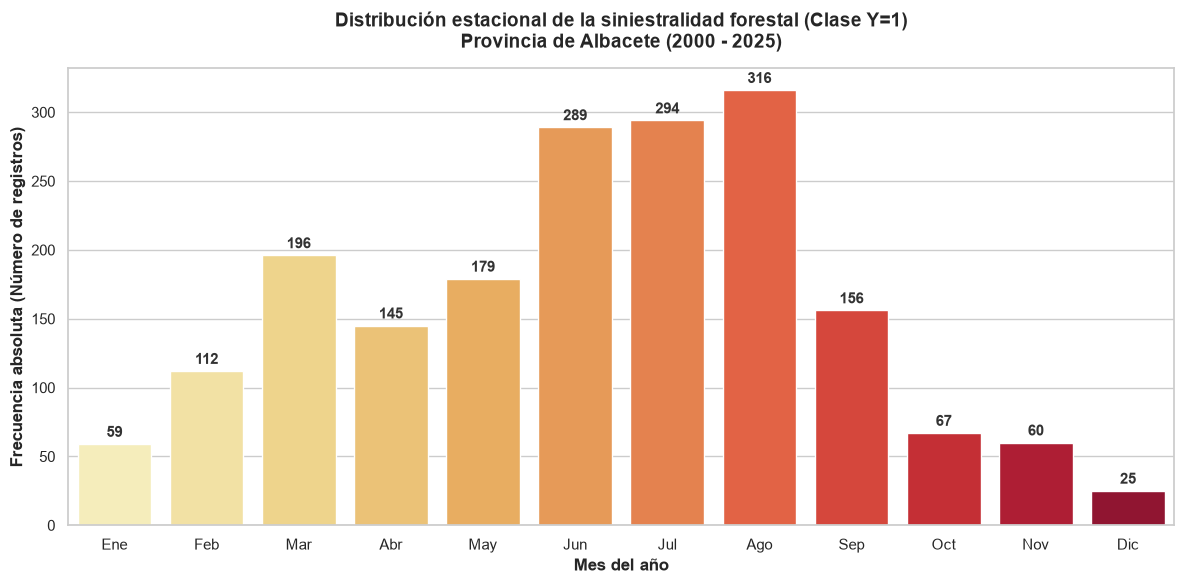

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Fase A.3: Análisis Exploratorio - Distribución mensual de la clase positiva (Y=1)...")

# --- 1. CONFIGURACIÓN DEL ENTORNO Y RUTAS ---
ruta_archivo = '../DATOS/1.INCENDIOS/BASE_INCENDIOS_LATLON.csv' 
ruta_imagen = 'distribucion_mensual_incendios.png'

# Configuración del marco estético para publicaciones académicas
sns.set_theme(style="whitegrid")

# --- 2. CARGA Y PREPROCESAMIENTO TEMPORAL ---
df_incendios = pd.read_csv(ruta_archivo)

# Transformación de la variable temporal y extracción de la componente mensual
df_incendios['Fecha'] = pd.to_datetime(df_incendios['Fecha'])
df_incendios['Mes'] = df_incendios['Fecha'].dt.month

# Agrupación y cálculo de frecuencias absolutas
conteo_meses = df_incendios['Mes'].value_counts().sort_index()

# --- 3. GENERACIÓN DE LA FIGURA ---
plt.figure(figsize=(12, 6))

nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Renderizado del diagrama de barras con paleta térmica secuencial
ax = sns.barplot(x=conteo_meses.index, y=conteo_meses.values, palette="YlOrRd")

# Estilización de la planimetría y etiquetado
plt.title('Distribución estacional de la siniestralidad forestal (Clase Y=1)\nProvincia de Albacete (2000 - 2025)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mes del año', fontsize=12, fontweight='bold')
plt.ylabel('Frecuencia absoluta (Número de registros)', fontsize=12, fontweight='bold')

plt.xticks(ticks=range(12), labels=nombres_meses, fontsize=11)
plt.yticks(fontsize=11)

# --- 4. ANOTACIÓN VECTORIAL DE FRECUENCIAS ---
# Iteración sobre los elementos gráficos para superponer el valor numérico exacto
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontsize=11, fontweight='bold', color='#333333')

# --- 5. EXPORTACIÓN DE LA FIGURA ---
plt.tight_layout()
plt.savefig(ruta_imagen, dpi=300, bbox_inches='tight')

print("-" * 50)
print(f"Gráfico exportado exitosamente en alta resolución: {ruta_imagen}")
print("-" * 50)

plt.show()